06 - weak labeling & dataset prep for ML

goal:
to build an labeled training, validation and test dataset for ml:
1. target labels:
- paragraph_type: exception, no_exception, cuec, subservice, other
- cuec_category: access control, endpoint_security, incident_management, backup_recovery, data_protection, monitoring, governance etc
2. apply weak labeling heuristics based on the regex rule from notebook3-5

In [1]:
# CONFIG CELL - Execution parameters and directory paths
import os
import sys
from pathlib import Path

# Dynamically locate project root
CWD = Path(os.getcwd()).resolve()
if (CWD / "data").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
elif (CWD / "socrr" / "data").exists():
    PROJECT_ROOT = CWD / "socrr"
else:
    PROJECT_ROOT = CWD

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_LABELED_DIR = PROJECT_ROOT / "data" / "labeled"
INTERNAL_CONTROLS_DIR = PROJECT_ROOT / "data" / "internal_controls"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

for d in [DATA_INTERIM_DIR, DATA_LABELED_DIR, INTERNAL_CONTROLS_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"[CONFIG] Project Root: {PROJECT_ROOT}")
print(f"[CONFIG] Interim Data: {DATA_INTERIM_DIR}")
print(f"[CONFIG] Outputs Dir:  {OUTPUTS_DIR}")

# Labeling Parameters
RANDOM_SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
MIN_EXAMPLES_PER_CLASS = 15

[CONFIG] Project Root: D:\System and Organization controls 2 report info extraction
[CONFIG] Interim Data: D:\System and Organization controls 2 report info extraction\data\interim
[CONFIG] Outputs Dir:  D:\System and Organization controls 2 report info extraction\outputs


Step 1 - lib

In [2]:
import json
import logging
from typing import List, Dict, Any, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("SOCRR_DatasetPrep")

SYNTHETIC_CUEC_SAMPLES = [
    ("User entities must configure strong password complexity rules and account lockout after 5 failed attempts.", "access_control"),
    ("User entities must enforce multi-factor authentication (MFA) for all administrative logins to cloud portals.", "access_control"),
    ("User entities are responsible for deprovisioning user accounts immediately upon employee departure.", "access_control"),
    ("User entities must maintain up-to-date endpoint detection and response (EDR) software on all client devices.", "endpoint_security"),
    ("User entities must ensure local firewall rules block unauthorized outbound remote desktop connections.", "endpoint_security"),
    ("User entities must notify the vendor security operations center within 24 hours of discovering credential theft.", "incident_management"),
    ("User entities must establish an incident escalation path for security events affecting cloud integrations.", "incident_management"),
    ("User entities are responsible for daily backups of locally maintained databases and offline copies.", "backup_recovery"),
    ("User entities must periodically test restoration procedures from disaster recovery snapshots.", "backup_recovery"),
    ("User entities must properly classify sensitive personal data and encrypt customer files prior to upload.", "data_protection"),
    ("User entities must rotate client API keys and cryptographic secrets at least annually.", "data_protection")
]

SYNTHETIC_EXCEPTION_SAMPLES = [
    ("Exception noted: For 3 of 40 sampled user terminations, access was revoked 5 days after departure.", "access_control"),
    ("Exception noted: For 1 of 25 sampled code deployments, peer review approval was not documented in GitHub.", "change_management"),
    ("Exception noted: For 1 of 4 quarterly disaster recovery drills, test sign-off was missing.", "backup_recovery"),
    ("Exception noted: 2 servers were missing critical OS security patches beyond the 30-day SLA window.", "endpoint_security"),
    ("Exception noted: For 4 administrative accounts, MFA was not enforced due to legacy service account configuration.", "access_control")
]

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


step 2 - aggregate real interim extractions and apply weak labels

pulling all extracted controls, cuec, subservice, and general section narrative paragrpahs

In [3]:
def collect_dataset_records() -> List[Dict[str, Any]]:
    """Extract paragraphs and weak labels from interim files."""
    records = []
    
    # 1. Collect from Controls files
    ctrl_files = list(DATA_INTERIM_DIR.glob("*_controls.json"))
    for cf in ctrl_files:
        with open(cf, "r", encoding="utf-8") as f:
            controls = json.load(f)
        for c in controls:
            if c["is_exception"]:
                ptype = "exception"
                text_content = f"{c['control_description']} Test: {c['test_performed']} Result: {c['test_result']}"
            else:
                ptype = "no_exception"
                text_content = f"{c['control_description']} Test: {c['test_performed']} Result: {c['test_result']}"
                
            records.append({
                "text": text_content,
                "paragraph_type": ptype,
                "cuec_category": "none",
                "source": cf.name,
                "is_synthetic": False
            })
            
    # 2. Collect from Subservice & CUEC files
    sc_files = list(DATA_INTERIM_DIR.glob("*_subservice_cuec.json"))
    for scf in sc_files:
        with open(scf, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        for cuec in data.get("cuecs", []):
            records.append({
                "text": cuec["text"],
                "paragraph_type": "cuec",
                "cuec_category": cuec.get("category", "other"),
                "source": scf.name,
                "is_synthetic": False
            })
            
        for s in data.get("subservice_organizations", []):
            records.append({
                "text": f"Subservice Organization: {s['name']}. Services: {s['services']}. Reporting Method: {s['method']}.",
                "paragraph_type": "subservice",
                "cuec_category": "none",
                "source": scf.name,
                "is_synthetic": False
            })
            
    # 3. Collect from Section III / V body text (Other)
    sec_files = list(DATA_INTERIM_DIR.glob("*_sections.json"))
    for sf in sec_files:
        with open(sf, "r", encoding="utf-8") as f:
            sections = json.load(f)
        sec3 = sections.get("section_3_system_description", {}).get("text", "")
        # Grab narrative paragraphs
        paras = [p.strip() for p in sec3.split("\n\n") if len(p.strip()) > 80]
        for p in paras[:15]:
            if not any(w in p.lower() for w in ["cuec", "user entit", "subservice", "sub-service"]):
                records.append({
                    "text": p,
                    "paragraph_type": "other",
                    "cuec_category": "none",
                    "source": sf.name,
                    "is_synthetic": False
                })
                
    # 4. Augment with synthetic samples if needed to ensure class balance
    raw_pdf_count = len(list(DATA_RAW_DIR.glob("*.pdf")))
    print(f"Discovered {len(records)} raw extracted records (raw PDFs: {raw_pdf_count}).")
    
    # Always supplement with synthetic examples if dataset is small
    if len(records) < 100 or raw_pdf_count < 3:
        logger.info("Adding synthetic examples for robust training and class balance.")
        for txt, cat in SYNTHETIC_CUEC_SAMPLES * 3:
            records.append({
                "text": txt,
                "paragraph_type": "cuec",
                "cuec_category": cat,
                "source": "synthetic_generator",
                "is_synthetic": True
            })
        for txt, cat in SYNTHETIC_EXCEPTION_SAMPLES * 4:
            records.append({
                "text": txt,
                "paragraph_type": "exception",
                "cuec_category": cat,
                "source": "synthetic_generator",
                "is_synthetic": True
            })
            
    return records

step 3 - split dataset into train, validation and test

Discovered 226 raw extracted records (raw PDFs: 3).
Total dataset records: 226
Synthetic records:    0
Real records:         226
Exported review template to D:\System and Organization controls 2 report info extraction\data\labeled\dataset_for_review.csv
Splits saved: Train=158, Val=34, Test=34


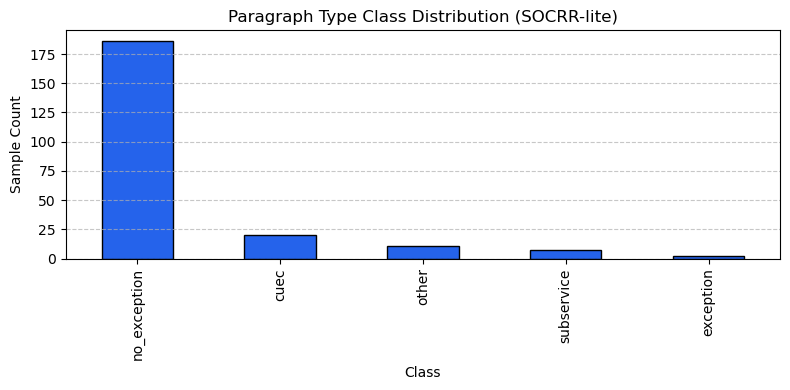

In [5]:
records = collect_dataset_records()
df_all = pd.DataFrame(records)

print(f"Total dataset records: {len(df_all)}")
print(f"Synthetic records:    {df_all['is_synthetic'].sum()}")
print(f"Real records:         {(~df_all['is_synthetic']).sum()}")

# Export dataset for human review and label correction
review_csv = DATA_LABELED_DIR / "dataset_for_review.csv"
df_all.to_csv(review_csv, index=False)
print(f"Exported review template to {review_csv}")

# Train / Val / Test Split (guaranteed safe stratification)
def safe_train_val_test_split(df: pd.DataFrame, target_col: str = "paragraph_type", 
                               val_ratio: float = 0.15, test_ratio: float = 0.15, seed: int = 42):
    min_count = df[target_col].value_counts().min()
    can_stratify = (min_count >= 3)
    strat_col = df[target_col] if can_stratify else None
    
    train_split, temp_split = train_test_split(
        df, test_size=(val_ratio + test_ratio),
        random_state=seed,
        stratify=strat_col
    )
    
    min_temp = temp_split[target_col].value_counts().min()
    can_strat_temp = (can_stratify and min_temp >= 2)
    strat_temp_col = temp_split[target_col] if can_strat_temp else None
    
    val_split, test_split = train_test_split(
        temp_split, test_size=0.5,
        random_state=seed,
        stratify=strat_temp_col
    )
    return train_split, val_split, test_split

train_df, val_df, test_df = safe_train_val_test_split(
    df_all, target_col="paragraph_type", 
    val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, seed=RANDOM_SEED
)

train_df.to_csv(DATA_LABELED_DIR / "train.csv", index=False)
val_df.to_csv(DATA_LABELED_DIR / "val.csv", index=False)
test_df.to_csv(DATA_LABELED_DIR / "test.csv", index=False)

split_summary = {
    "total_samples": len(df_all),
    "train_samples": len(train_df),
    "val_samples": len(val_df),
    "test_samples": len(test_df),
    "class_distribution": df_all["paragraph_type"].value_counts().to_dict(),
    "synthetic_ratio": float(df_all["is_synthetic"].mean())
}

with open(DATA_LABELED_DIR / "dataset_splits.json", "w", encoding="utf-8") as f:
    json.dump(split_summary, f, indent=2)

print(f"Splits saved: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

plt.figure(figsize=(8, 4))
df_all["paragraph_type"].value_counts().plot(kind="bar", color="#2563eb", edgecolor="black")
plt.title("Paragraph Type Class Distribution (SOCRR-lite)")
plt.xlabel("Class")
plt.ylabel("Sample Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

step 4 - sanity check

In [6]:
assert (DATA_LABELED_DIR / "train.csv").exists()
assert (DATA_LABELED_DIR / "val.csv").exists()
assert (DATA_LABELED_DIR / "test.csv").exists()

assert not train_df["text"].isnull().any(), "Train set contains null text!"
assert len(train_df["paragraph_type"].unique()) >= 4, "Too few classes represented in train split!"

print("Sanity Check Passed: Labeled dataset generated, partitioned, and verified.")

Sanity Check Passed: Labeled dataset generated, partitioned, and verified.
